In [48]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [49]:
#Part 1. Building DataFrame and Define ML Problem

In [52]:
df = pd.read_csv("cell2celltrain.csv", header=0)

In [53]:
df.shape

(51047, 85)

In [54]:
df.head()

,CustomerID,Churn,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,HomeownershipKnown,BuysViaMailOrder,RespondsToMailOffers,...,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,Married_False,Married_True,Married_nan
0,3000002,True,False,False,True,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3000010,True,True,False,False,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3000014,False,True,False,False,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3000022,False,False,False,True,False,False,True,True,True,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,3000026,True,False,False,False,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [55]:
#Part 2. Prepare Data

#Identify and Handle Missing Data 
nan_count = np.sum(df.isnull(), axis = 0)
nan_count


CustomerID            0
Churn                 0
ChildrenInHH          0
HandsetRefurbished    0
HandsetWebCapable     0
                     ..
Occupation_Self       0
Occupation_Student    0
Married_False         0
Married_True          0
Married_nan           0
Length: 85, dtype: int64

In [56]:
nan_count[nan_count > 0]

Series([], dtype: int64)

In [57]:
# df.drop(columns=["Married"], inplace=True)
#df['someColString'].fillna('unavailable', inplace=True)

In [58]:
np.sum(df.isnull(), axis=0)

CustomerID            0
Churn                 0
ChildrenInHH          0
HandsetRefurbished    0
HandsetWebCapable     0
                     ..
Occupation_Self       0
Occupation_Student    0
Married_False         0
Married_True          0
Married_nan           0
Length: 85, dtype: int64

In [60]:
#Perform One Hot Encoding 
#To train DT:
#Tranform string value featres to numerical boolean value

df.dtypes

CustomerID              int64
Churn                    bool
ChildrenInHH             bool
HandsetRefurbished       bool
HandsetWebCapable        bool
                       ...   
Occupation_Self       float64
Occupation_Student    float64
Married_False         float64
Married_True          float64
Married_nan           float64
Length: 85, dtype: object

In [61]:
to_encode = list(df.select_dtypes(include=['object']).columns)

In [62]:
df[to_encode].nunique()

# ServiceArea 748
# CreditRating 7
# PrizmCode 4
# Occupation 8
# dtype: int64

Series([], dtype: float64)

In [63]:
#Get top 10 freq ServiceArea values instead of 748

# top_10_SA = list(df['ServiceArea'].value_counts().head(10).index)
# .index bc just want category name (value) , No need count

In [25]:
# for value in top_10_SA:
#     df['ServiceArea_' + value] = np.where(df['ServiceArea']==value,1,0)

In [27]:
# df.drop(columns='ServiceArea', inplace=True)
# to_encode.remove('ServiceArea')

In [64]:
df.columns


Index(['CustomerID', 'Churn', 'ChildrenInHH', 'HandsetRefurbished',
       'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'HomeownershipKnown',
       'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings',
       'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser',
       'NotNewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam',
       'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
       'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls',
       'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls',
       'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls',
       'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut',
       'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls',
       'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs',
       'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2',
       'RetentionCalls', 'RetentionOffersAccepted',
    

In [65]:
df.head()

,CustomerID,Churn,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,HomeownershipKnown,BuysViaMailOrder,RespondsToMailOffers,...,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,Married_False,Married_True,Married_nan
0,3000002,True,False,False,True,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3000010,True,True,False,False,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3000014,False,True,False,False,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3000022,False,False,False,True,False,False,True,True,True,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,3000026,True,False,False,False,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Check that ServiceArea_DALDAL214 in row 47 is 1
# df.loc[47]['ServiceArea_DALDAL214']

In [32]:
# for colname in to_encode:
#     df_encoded = pd.get_dummies(df[colname], prefix=colname + '_')
#     df = df.join(df_encoded)

# pd.get_dummies() convert cate values into 0/1 columns

In [33]:
# df.drop(columns=to_encode, axis=1, inplace=True)

In [66]:
df.isnull().values.any()

np.False_

In [67]:
list(df.loc[:,df.columns != 'Churn'])
#all row, all col except the col = Churn. List iterate in and return col 

['CustomerID',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'HomeownershipKnown',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'OwnsMotorcycle',
 'MadeCallToRetentionTeam',
 'MonthlyRevenue',
 'MonthlyMinutes',
 'TotalRecurringCharge',
 'DirectorAssistedCalls',
 'OverageMinutes',
 'RoamingCalls',
 'PercChangeMinutes',
 'PercChangeRevenues',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'CustomerCareCalls',
 'ThreewayCalls',
 'ReceivedCalls',
 'OutboundCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'DroppedBlockedCalls',
 'CallForwardingCalls',
 'CallWaitingCalls',
 'MonthsInService',
 'UniqueSubs',
 'ActiveSubs',
 'Handsets',
 'HandsetModels',
 'CurrentEquipmentDays',
 'AgeHH1',
 'AgeHH2',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'ReferralsMadeBySubscriber',
 'IncomeGroup',
 'AdjustmentsToCr

In [68]:
y = df['Churn']
X = df.drop(columns = 'Churn', axis=1)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=123)

In [70]:
print(X_train.shape)
print(X_test.shape)

(35732, 84)
(15315, 84)


In [71]:
def train_test_DT(X_train, X_test, y_train, y_test, depth, leaf=1, crit='entropy'):
    model = DecisionTreeClassifier(criterion= crit, max_depth = depth, min_samples_leaf=leaf)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = accuracy_score(y_test, pred)
    return score

In [ ]:
#Compare diff hyperparameters 
depth1 = 2
depth2 = 5

max_depth_range = [depth1, depth2]
acc = []

for md in max_depth_range:
    score = train_test_DT(X_train, X_test, y_train, y_test, md)
    print('Max Depth=' + str(md) + ', accuracy score: ' + str(score))
    acc.append(score)


Max Depth=2, accuracy score: 0.7107411034933072
Max Depth=5, accuracy score: 0.715834149526608


<>:6: SyntaxWarning: invalid escape sequence '\_'
<>:6: SyntaxWarning: invalid escape sequence '\_'
/var/folders/3p/z7301m2x50g0m2zv0lkgh48h0000gn/T/ipykernel_3114/3329771471.py:6: SyntaxWarning: invalid escape sequence '\_'
  plt.title('Test set accuracy of the DT predictions, for $max\_depth\in\{2,5\}$')


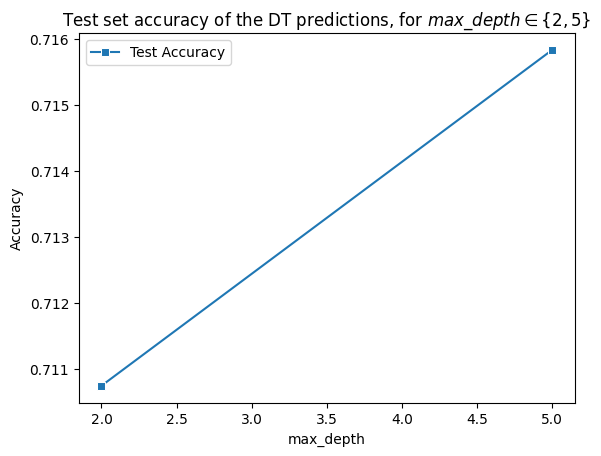

In [78]:
#Visualize result w seaborn lineplot 
fig = plt.figure()
ax = fig.add_subplot(111)

p = sns.lineplot(x=max_depth_range, y = acc, marker='s', label = 'Test Accuracy')
plt.title('Test set accuracy of the DT predictions, for $max\_depth\in\{2,5\}$')

ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
plt.show()


Analysis:
With a deeper depth length, the Tree was able to make more precise observation of the rules. In our case, we see that max depth of 5 has a 0.05 higher accuracy score then max depth of 2. 

Balancing the degree of hyperparameter (depth level):
- not too deep causing overfitting
- not too shallow causing underestimate 